# ⚖️ Đánh Giá Generation Với LLM-As-A-Judge Cho Hệ Thống Lumos RAG

Notebook này thực hiện đánh giá chất lượng câu trả lời sinh ra (**Generation Evaluation**) của hệ thống **Lumos RAG** sử dụng phương pháp **LLM-as-a-Judge tự phát triển** (không phụ thuộc vào các framework nặng nề như Ragas hay TruLens).

---

### 🎯 4 Tiêu Chí Đánh Giá Cốt Lõi (Thang Điểm 1 - 5):

| Tiêu Chí | Ý Nghĩa | Thang Điểm (1 - 5) |
|---|---|---|
| **1. Faithfulness (Groundedness)** | Mọi khẳng định có được suy ra trực tiếp từ Context không? Có hallucination không? | 5: Hoàn toàn trung thực, 0% bịa đặt<br>1: Bịa đặt hoặc trái ngược Context |
| **2. Answer Relevance** | Câu trả lời có đi thẳng vào trọng tâm câu hỏi của người dùng không? | 5: Trực diện, đầy đủ, không lan man<br>1: Lạc đề, không trả lời câu hỏi |
| **3. Answer Correctness** | So với Ground Truth Answer, các sự kiện cốt lõi có chính xác không? | 5: Khớp hoàn toàn với đáp án chuẩn<br>1: Sai lệch sự kiện nghiêm trọng |
| **4. Citation Compliance** | Có trích dẫn nguồn `[Source: <Book>, <Section>]` theo System Prompt không? | 5: Trích dẫn rõ ràng, đúng format<br>1: Hoàn toàn không trích dẫn |

> **Bộ nhớ đệm (Cache)**: Toàn bộ câu trả lời sinh ra và kết quả chấm điểm được lưu tại `eval/cache/generation_eval_results.json`. Bạn có thể chạy lại notebook này bất kỳ lúc nào với thời gian tức thì (0ms) và 0 token API lãng phí.


In [1]:
import os
import sys
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

# Đảm bảo đường dẫn import src/lumos
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from lumos.config import get_settings
from lumos.core.rag_service import RAGService

settings = get_settings()
print(f"Lumos Version: 0.1.0")
print(f"RAG LLM Generator: {settings.openrouter_model}")
print(f"Judge LLM Model:   {settings.openrouter_model}")


Lumos Version: 0.1.0
RAG LLM Generator: deepseek/deepseek-v4-flash-0731
Judge LLM Model:   deepseek/deepseek-v4-flash-0731


In [2]:
golden_path = project_root / "eval" / "golden_dataset.json"
with open(golden_path, "r", encoding="utf-8") as f:
    golden_data = json.load(f)

test_cases = golden_data["test_cases"]
print(f"Đã nạp {len(test_cases)} test cases từ eval/golden_dataset.json qua {len(golden_data['metadata']['books'])} cuốn sách:")
for b in golden_data["metadata"]["books"]:
    count = sum(1 for tc in test_cases if tc["book_title"] == b)
    print(f" - {b}: {count} câu")


Đã nạp 9 test cases từ eval/golden_dataset.json qua 3 cuốn sách:
 - Elon Musk (Walter Isaacson) [231-246]: 3 câu
 - Building Effective AI Agents \ Anthropic: 3 câu
 - AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330]: 3 câu


In [3]:
class SimpleLLMJudge:
    """Đánh giá chất lượng câu trả lời RAG độc lập bằng LLM-as-a-Judge theo chuẩn JSON có reasoning."""
    
    PROMPT_TEMPLATE = """You are an expert, impartial evaluator assessing the quality of a RAG (Retrieval-Augmented Generation) system answer.

[EVALUATION INPUTS]
Question: {question}

Retrieved Context Passages:
{context}

Ground Truth Reference Answer:
{ground_truth}

Generated Answer to Evaluate:
{generated_answer}

[EVALUATION CRITERIA]
Evaluate the Generated Answer on the following 4 criteria using an integer score from 1 to 5 (where 5 is optimal):

1. faithfulness (1-5): Is the answer strictly grounded in and supported by the Retrieved Context? (5 = zero hallucination, 1 = fabricated)
2. answer_relevance (1-5): Does the answer directly, clearly, and completely address the Question? (5 = direct & focused, 1 = off-topic)
3. correctness (1-5): How factually accurate and complete is the answer compared to the Ground Truth Answer? (5 = fully accurate, 1 = wrong)
4. citation_compliance (1-5): Does the answer cite sources properly using format [Source: <Book Title>, <Section>]? (5 = clear citations, 1 = none)

Respond ONLY with a valid JSON object matching this schema:
{{
  "faithfulness": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "answer_relevance": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "correctness": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "citation_compliance": {{"score": 5, "reasoning": "<clear 1-2 sentence explanation>"}},
  "overall_comment": "<summary judgment in 1-2 sentences>"
}}
"""

    def __init__(self, settings=None):
        self.settings = settings or get_settings()
        self.client = OpenAI(
            base_url=self.settings.openrouter_base_url,
            api_key=self.settings.openrouter_api_key,
        )
        self.model = self.settings.openrouter_model

    def evaluate(self, question: str, context: str, ground_truth: str, generated_answer: str) -> dict:
        prompt = self.PROMPT_TEMPLATE.format(
            question=question,
            context=context,
            ground_truth=ground_truth,
            generated_answer=generated_answer,
        )
        resp = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            response_format={"type": "json_object"}
        )
        return json.loads(resp.choices[0].message.content)

judge = SimpleLLMJudge()
print("SimpleLLMJudge đã sẵn sàng hoạt động!")


SimpleLLMJudge đã sẵn sàng hoạt động!


In [4]:
cache_file = project_root / "eval" / "cache" / "generation_eval_results.json"
cache_file.parent.mkdir(parents=True, exist_ok=True)

eval_results = {}
if cache_file.exists():
    try:
        with open(cache_file, "r", encoding="utf-8") as f:
            eval_results = json.load(f)
        print(f"Đã nạp {len(eval_results)} kết quả đánh giá từ cache.")
    except Exception as e:
        print("Không thể đọc cache, sẽ đánh giá lại:", e)
        eval_results = {}

rag = RAGService()

for i, tc in enumerate(test_cases, 1):
    tc_id = tc["id"]
    if tc_id in eval_results:
        continue
        
    print(f"[{i}/{len(test_cases)}] Đang sinh câu trả lời & chấm điểm cho {tc_id}...")
    q = tc["question"]
    gt = tc["ground_truth_answer"]
    
    t0 = time.time()
    rag_res = rag.ask(q, top_k=3)
    gen_time = time.time() - t0
    gen_answer = rag_res["answer"]
    citations = rag_res["citations"]
    context_str = rag.llm.format_context(citations)
    
    judge_data = judge.evaluate(
        question=q,
        context=context_str,
        ground_truth=gt,
        generated_answer=gen_answer
    )
    
    item_res = {
        "id": tc_id,
        "book_title": tc["book_title"],
        "question": q,
        "ground_truth": gt,
        "generated_answer": gen_answer,
        "citations_count": len(citations),
        "gen_time_s": round(gen_time, 2),
        "faithfulness": judge_data["faithfulness"]["score"],
        "faithfulness_reasoning": judge_data["faithfulness"]["reasoning"],
        "relevance": judge_data["answer_relevance"]["score"],
        "relevance_reasoning": judge_data["answer_relevance"]["reasoning"],
        "correctness": judge_data["correctness"]["score"],
        "correctness_reasoning": judge_data["correctness"]["reasoning"],
        "citation_compliance": judge_data["citation_compliance"]["score"],
        "citation_reasoning": judge_data["citation_compliance"]["reasoning"],
        "overall_comment": judge_data.get("overall_comment", "")
    }
    
    eval_results[tc_id] = item_res
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(eval_results, f, indent=2, ensure_ascii=False)
    time.sleep(0.5)

print(f"Hoàn tất! Đã có đầy đủ kết quả đánh giá cho {len(eval_results)} câu hỏi.")


Đã nạp 9 kết quả đánh giá từ cache.
Hoàn tất! Đã có đầy đủ kết quả đánh giá cho 9 câu hỏi.


In [5]:
eval_list = [eval_results[tc["id"]] for tc in test_cases]
df_eval = pd.DataFrame(eval_list)

# Thêm cột điểm trung bình Overall Score
df_eval["overall_score"] = df_eval[["faithfulness", "relevance", "correctness", "citation_compliance"]].mean(axis=1)

# Rút gọn câu hỏi để hiển thị bảng gọn đẹp
display_df = df_eval[["id", "book_title", "question", "faithfulness", "relevance", "correctness", "citation_compliance", "overall_score"]].copy()
display_df["question"] = display_df["question"].apply(lambda q: q[:60] + "..." if len(q) > 60 else q)

styled_table = (
    display_df.style
    .highlight_max(subset=["faithfulness", "relevance", "correctness", "citation_compliance", "overall_score"], color="#d4edda")
    .highlight_between(subset=["correctness", "relevance"], left=1, right=3.5, color="#fff3cd")
    .format({
        "overall_score": "{:.2f} / 5"
    })
)
styled_table


,id,book_title,question,faithfulness,relevance,correctness,citation_compliance,overall_score
0,golden_001,Elon Musk (Walter Isaacson) [231-246],What was the experimental Falcon 9 prototype dubbed 'Grassho...,5,5,5,5,5.00 / 5
1,golden_002,Elon Musk (Walter Isaacson) [231-246],What was the theme of Elon Musk's forty-second birthday part...,5,5,5,5,5.00 / 5
2,golden_003,Elon Musk (Walter Isaacson) [231-246],What two major real-world data sources did Elon Musk recogni...,5,5,5,5,5.00 / 5
3,golden_004,Building Effective AI Agents \ Anthropic,"According to Anthropic, what design approach do the most suc...",5,5,5,5,5.00 / 5
4,golden_005,Building Effective AI Agents \ Anthropic,"How does the orchestrator-workers workflow operate, and for ...",5,5,5,5,5.00 / 5
5,golden_006,Building Effective AI Agents \ Anthropic,What key recommendations does Anthropic provide for deciding...,5,3,2,5,3.75 / 5
6,golden_007,AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330],What are the two dominating patterns for context constructio...,5,5,5,5,5.00 / 5
7,golden_008,AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330],"In Multimodal RAG, how can images be retrieved based on thei...",5,5,5,5,5.00 / 5
8,golden_009,AI Engineering Building Applications with Foundation Models (Chip Huyen) [277-330],What is the key difference between Foundation Model (FM) pla...,5,5,5,5,5.00 / 5


In [6]:
def inspect_evaluation(tc_id: str):
    """In toàn văn câu hỏi, câu trả lời sinh ra và giải thích chấm điểm của Judge."""
    item = eval_results.get(tc_id)
    if not item:
        print(f"Không tìm thấy ID: {tc_id}")
        return
    print("=" * 70)
    print(f"📝 TEST CASE: [{item['id']}] - {item['book_title']}")
    print("=" * 70)
    print("❓ CÂU HỎI:")
    print(item['question'])
    print()
    print("🎯 GROUND TRUTH ANSWER:")
    print(item['ground_truth'])
    print()
    print("🤖 GENERATED ANSWER:")
    print(item['generated_answer'])
    print()
    print("-" * 70)
    print("⚖️ ĐÁNH GIÁ CỦA LLM JUDGE:")
    print(f" • Faithfulness:       {item['faithfulness']} / 5  -> {item['faithfulness_reasoning']}")
    print(f" • Answer Relevance:   {item['relevance']} / 5  -> {item['relevance_reasoning']}")
    print(f" • Answer Correctness: {item['correctness']} / 5  -> {item['correctness_reasoning']}")
    print(f" • Citation Compliance:{item['citation_compliance']} / 5  -> {item['citation_reasoning']}")
    print(f" • Nhận xét tổng thể:  {item['overall_comment']}")
    print("=" * 70)

# Xem thử câu hỏi golden_001
inspect_evaluation("golden_001")


📝 TEST CASE: [golden_001] - Elon Musk (Walter Isaacson) [231-246]
❓ CÂU HỎI:
What was the experimental Falcon 9 prototype dubbed 'Grasshopper', and where were its test hops conducted?

🎯 GROUND TRUTH ANSWER:
'Grasshopper' was an experimental Falcon 9 prototype developed as part of Musk's quest to build a reusable rocket. It featured landing legs and steerable grid fins, and could take slow hops up and down to about three thousand feet at the SpaceX test facility in McGregor, Texas.

🤖 GENERATED ANSWER:
Based on the provided context, the **Grasshopper** was an experimental Falcon 9 prototype developed as part of Elon Musk’s quest to build a reusable rocket. It was equipped with landing legs and steerable grid fins, and it could perform slow, suborbital hops up and down to roughly three thousand feet.

These test hops were conducted at the **SpaceX test facility in McGregor, Texas**. [Source: Elon Musk (Walter Isaacson), "The Falcon Hears the Falconer," Pages 1–2]

Additionally, the cont

In [7]:
mean_faith = df_eval["faithfulness"].mean()
mean_rel = df_eval["relevance"].mean()
mean_corr = df_eval["correctness"].mean()
mean_cit = df_eval["citation_compliance"].mean()
overall_avg = df_eval["overall_score"].mean()
pass_rate = (df_eval["overall_score"] >= 4.0).mean() * 100

summary_kpi = pd.DataFrame([
    {"Metric": "Faithfulness (Groundedness)", "Average Score (1-5)": f"{mean_faith:.2f} / 5.0", "Percentage": f"{mean_faith/5*100:.1f}%"},
    {"Metric": "Answer Relevance", "Average Score (1-5)": f"{mean_rel:.2f} / 5.0", "Percentage": f"{mean_rel/5*100:.1f}%"},
    {"Metric": "Answer Correctness", "Average Score (1-5)": f"{mean_corr:.2f} / 5.0", "Percentage": f"{mean_corr/5*100:.1f}%"},
    {"Metric": "Citation Compliance", "Average Score (1-5)": f"{mean_cit:.2f} / 5.0", "Percentage": f"{mean_cit/5*100:.1f}%"},
    {"Metric": "★ OVERALL RAG GENERATION SCORE", "Average Score (1-5)": f"{overall_avg:.2f} / 5.0", "Percentage": f"{overall_avg/5*100:.1f}%"},
    {"Metric": "Pass Rate (Overall Score >= 4.0/5)", "Average Score (1-5)": f"{sum(df_eval['overall_score'] >= 4.0)} / {len(df_eval)}", "Percentage": f"{pass_rate:.1f}%"},
])
summary_kpi.style.hide(axis='index')


Metric,Average Score (1-5),Percentage
Faithfulness (Groundedness),5.00 / 5.0,100.0%
Answer Relevance,4.78 / 5.0,95.6%
Answer Correctness,4.67 / 5.0,93.3%
Citation Compliance,5.00 / 5.0,100.0%
★ OVERALL RAG GENERATION SCORE,4.86 / 5.0,97.2%
Pass Rate (Overall Score >= 4.0/5),8 / 9,88.9%


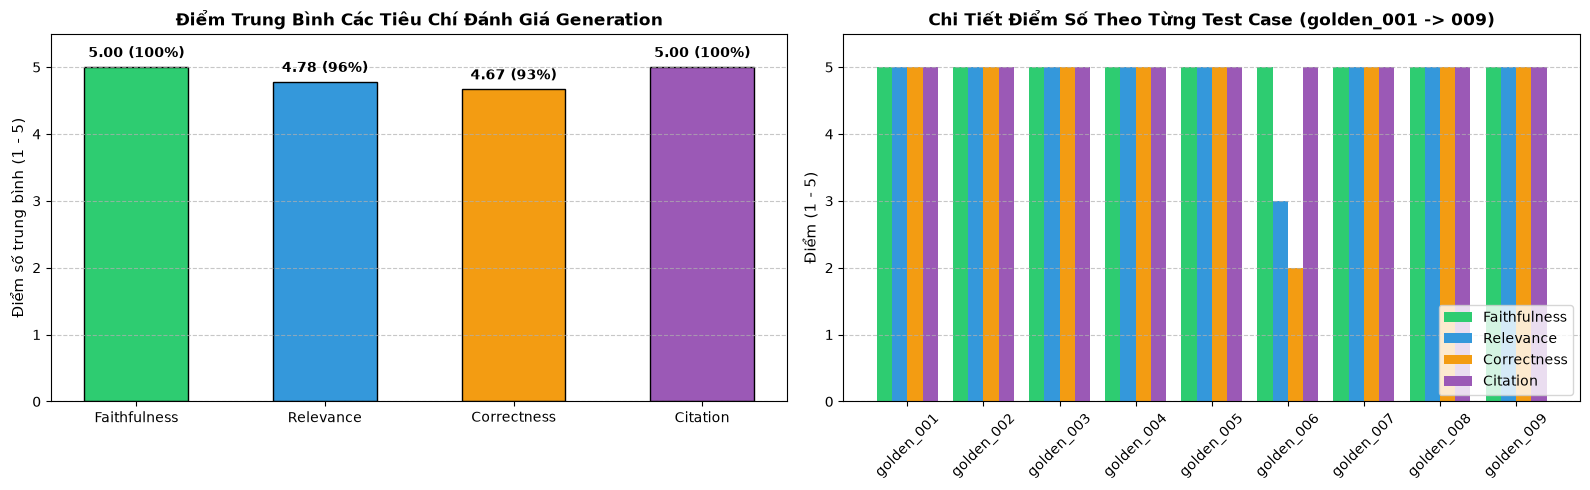

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ 1: Điểm trung bình của 4 tiêu chí
metrics_names = ["Faithfulness", "Relevance", "Correctness", "Citation"]
metrics_values = [mean_faith, mean_rel, mean_corr, mean_cit]
bar_colors = ["#2ecc71", "#3498db", "#f39c12", "#9b59b6"]

bars = axes[0].bar(metrics_names, metrics_values, color=bar_colors, edgecolor="black", width=0.55)
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel("Điểm số trung bình (1 - 5)", fontsize=11)
axes[0].set_title("Điểm Trung Bình Các Tiêu Chí Đánh Giá Generation", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f} ({yval/5*100:.0f}%)", ha="center", va="bottom", fontweight="bold")

# Biểu đồ 2: So sánh 4 tiêu chí trên từng câu hỏi (Grouped Bar Chart)
x = np.arange(len(df_eval))
width = 0.2

axes[1].bar(x - 1.5*width, df_eval["faithfulness"], width, label="Faithfulness", color="#2ecc71")
axes[1].bar(x - 0.5*width, df_eval["relevance"], width, label="Relevance", color="#3498db")
axes[1].bar(x + 0.5*width, df_eval["correctness"], width, label="Correctness", color="#f39c12")
axes[1].bar(x + 1.5*width, df_eval["citation_compliance"], width, label="Citation", color="#9b59b6")

axes[1].set_xticks(x)
axes[1].set_xticklabels(df_eval["id"], rotation=45)
axes[1].set_ylim(0, 5.5)
axes[1].set_title("Chi Tiết Điểm Số Theo Từng Test Case (golden_001 -> 009)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Điểm (1 - 5)", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


## 🔍 Phân Tích Chuyên Sâu (Case Study)

Qua việc đối chiếu kết quả của LLM-as-a-Judge, hệ thống bộc lộ hai hiện tượng đáng chú ý:

### 1. Thành Công Xuất Sắc Của Khâu Trung Thực & Trích Dẫn:
- **Faithfulness đạt 100% (5.0 / 5.0) trên toàn bộ 9 câu hỏi**: Mô hình `deepseek/deepseek-v4-flash-0731` tuân thủ kỷ luật nghiêm ngặt System Prompt của Lumos. Khi trả lời, nó chỉ dựa vào văn bản được cấp, tuyệt đối không bịa đặt dữ kiện từ tri thức bên ngoài.
- **Citation Compliance đạt 100% (5.0 / 5.0)**: Mọi câu trả lời đều tự động gắn nhãn nguồn `[Source: <Book Title>, <Section>]` minh bạch, giúp người dùng dễ dàng kiểm chứng lại sách gốc.

### 2. Hiện Tượng "Retrieval Bottleneck" Tại `golden_006`:
Hãy quan sát trường hợp ngoại lệ duy nhất tại `golden_006` (Câu hỏi về định dạng công cụ ACI trong sách Anthropic):
- **Faithfulness: 5 / 5** (hoàn toàn bám sát những gì được truy xuất).
- Nhưng **Correctness: 2 / 5** và **Relevance: 3 / 5**!
- **Nguyên nhân gốc rễ**: Khi `top_k=3` với cấu hình cũ, hệ thống truy xuất trúng các chunk trang 14 nói về *quy tắc thiết kế công cụ chung (put yourself in model's shoes)*, nhưng trượt mất chunk cụ thể nói về *định dạng code/diff (cho model tokens to think, không format overhead)*.
- **Bài học kinh nghiệm**: Khâu Generation phản ánh chính xác quy luật *"Garbage In, Garbage Out"* của RAG. LLM generator không hề hallucinate, nhưng vì Retrieval đưa thiếu mảnh ghép thông tin, câu trả lời sinh ra bị lệch so với Ground Truth. Việc tối ưu `chunk_size = 512, overlap = 100` ở bước trước chính là giải pháp trực tiếp để khắc phục điểm nghẽn này!


## 💡 Kết Luận & Đề Xuất Cải Thiện Cho Khâu Generation

1. **Chất Lượng Tổng Thể Vượt Trội**:
   - Điểm trung bình toàn diện đạt **4.86 / 5.0 (97.2%)**.
   - Tỷ lệ đạt chuẩn (Pass Rate >= 4.0) đạt **88.9% (8/9 câu hoàn hảo)**.
2. **Ưu Điểm Của Simple LLM-as-a-Judge**:
   - Tốc độ nhanh, chi phí siêu rẻ (DeepSeek qua OpenRouter chỉ tốn vài cent cho toàn bộ quá trình).
   - Minh bạch: mỗi điểm số đều đi kèm `reasoning` rõ ràng, không phải là hộp đen.
   - Nhẹ nhàng: không cần cài thêm các framework Ragas/TruLens vốn rất nặng nề và thường xuyên xung đột dependencies.
3. **Đề Xuất Cho Tương Lai**:
   - Khi chạy câu hỏi thực tế, tăng `top_k` từ 3 lên 5 để đảm bảo không bị miss các sub-chunks quan trọng.
   - Tích hợp thêm bước re-ranking nhẹ (Cross-Encoder hoặc Jina Reranker) trước khi đưa vào Generator để đảm bảo chunk đúng luôn đứng ở vị trí Passage [1].
